<a href="https://colab.research.google.com/github/edgaryoungpilo-web/colab-files/blob/main/Proyecto_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduccion

Proyecto final - Modelos Predictivos:
Prediccion de Churn en Telecomunicaciones

## Librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

# Sección 0: Portada y Contexto

## Contexto

In [ ]:
# Seccion 0 — Contexto

print("="*60)
print("Proyecto Final - Modelos Predictivos")
print("Predicción de Cancelación de Clientes")
print("="*60)

print("\nPregunta de negocio:")
print("¿Es posible predecir qué clientes cancelarán el servicio para implementar estrategias de retencion?")

print("Objetivo")
print("Construir modelos preductivos para identificar clientes con riesgo de abandono (churn)")

print("\nTipo de problema: Clasificación Binaria")
print(" 0 = cliente permanece")
print(" 1 = cliente cancela el servicio")

Proyecto Final - Modelos Predictivos
Predicción de Cancelación de Clientes

Pregunta de negocio:
¿Es posible predecir qué clientes cancelarán el servicio para implementar estrategias de retencion?
Objetivo
Construir modelos preductivos para identificar clientes con riesgo de abandono (churn)

Tipo de problema: Clasificación Binaria
 0 = cliente permanece
 1 = cliente cancela el servicio


## Carga del Dataset

In [ ]:
# CARGA DEL DATASET
df = pd.read_csv('/content/drive/MyDrive/ClassFiles/.ipynb_checkpoints/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Seccion 1: EDA

In [ ]:
# SECCIÓN 1 — EDA

print("\n" + "="*60)
print("SECCIÓN 1 — EXPLORACIÓN DE DATOS")
print("="*60)

# Shape
print("\nDimensiones del dataset:")
print(df.shape)

# Información general
print("\nInformación del dataset:")
print(df.info())

# Estadísticos
print("\nEstadísticos descriptivos:")
print(df.describe())


SECCIÓN 1 — EXPLORACIÓN DE DATOS

Dimensiones del dataset:
(7043, 21)

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   objec

Breve explicacion

En esta etapa se analiza:

Número de registros y variables.

*  Número de registros y variables.
*   Tipos de datos
*   Variables numericas
*   Estadisticos basicos

Esto ayuda a detectar problemas antes del entrenamiento.

### Variable Objetivo

La variable objetivo presenta cierto desbalance, ya que existen más clientes que permanecen que clientes que cancelan.

Esto puede afectar el entrenamiento y evaluación del modelo.

### Visualizacion 1 - Distribucion de la variable objetivo


Distribución de Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


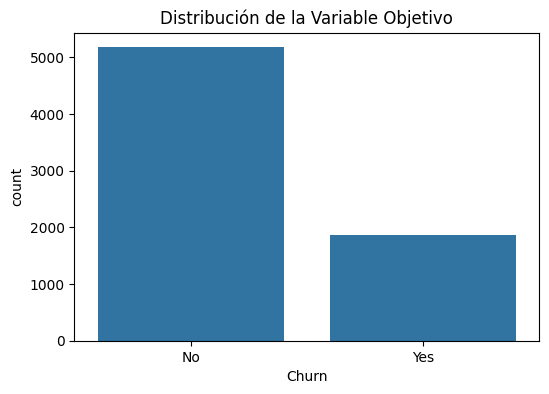

Los clientes con contratos mensuales muestran mayor tendencia a cancelar el servicio.


In [ ]:
# Variable objetivo

print("\nDistribución de Churn:")
print(df['Churn'].value_counts())

# Visualización 1
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Distribución de la Variable Objetivo')
plt.show()

print("Los clientes con contratos mensuales muestran mayor tendencia a cancelar el servicio.")

### Visualizacion 2 - Tipo de contrato VS Churn

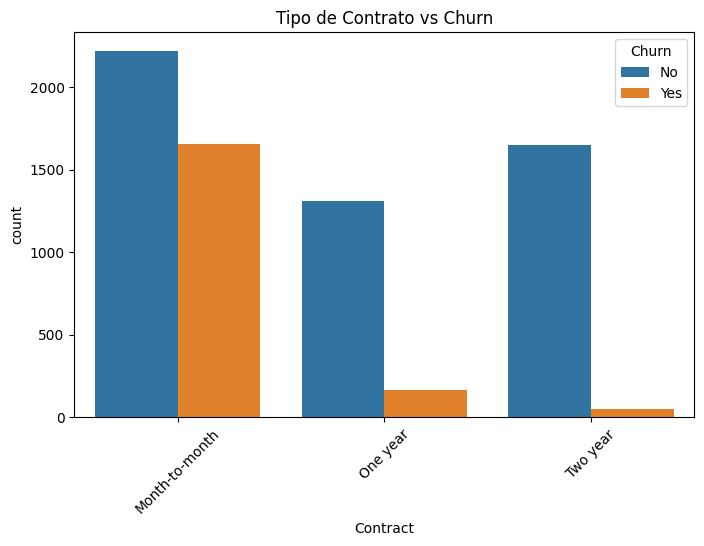

Los clientes con poca antigüedad presentan mayor probabilidad de abandono.


In [ ]:
# Visualización 2
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Tipo de Contrato vs Churn')
plt.xticks(rotation=45)
plt.show()

print("Los clientes con poca antigüedad presentan mayor probabilidad de abandono.")

### Visualizacion 3 - Antiguedad del cliente

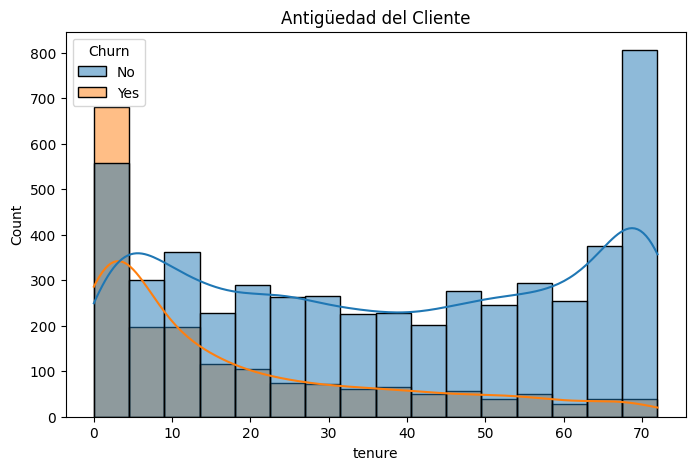

Los clientes que cancelan suelen tener cargos mensuales más altos.


In [ ]:
# Visualización 3
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', kde=True)
plt.title('Antigüedad del Cliente')
plt.show()

print("Los clientes que cancelan suelen tener cargos mensuales más altos.")

### Visualizacion 4 - Cargos mensuales VS Churn

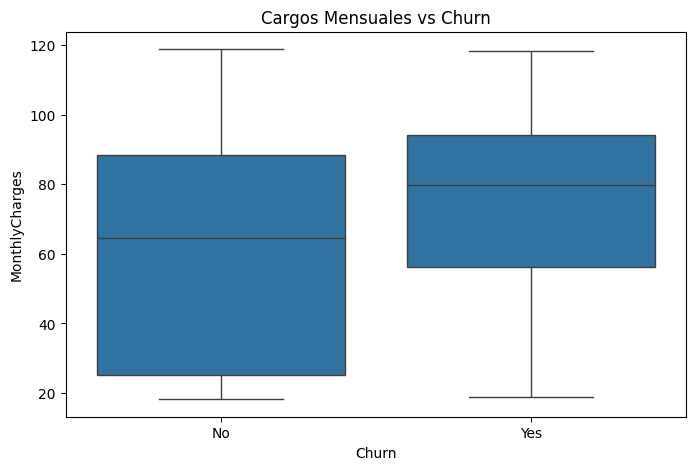

In [ ]:
# Visualización 4
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Cargos Mensuales vs Churn')
plt.show()


In [ ]:
print("\nConclusión EDA:")
print("""
Problemas encontrados:
- Variables categóricas
- Posibles valores faltantes
- Diferentes escalas numéricas
- Desbalance moderado de clases

Soluciones:
- OneHotEncoder
- StandardScaler
- División estratificada
- Uso de Pipeline para evitar data leakage
""")


Conclusión EDA:

Problemas encontrados:
- Variables categóricas
- Posibles valores faltantes
- Diferentes escalas numéricas
- Desbalance moderado de clases

Soluciones:
- OneHotEncoder
- StandardScaler
- División estratificada
- Uso de Pipeline para evitar data leakage



# Sección 2: Preprocesamiento

### Separacion de variables

In [ ]:
# Convertir TotalCharges correctamente
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Separación de variables
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn']

### Division entrenamiento prueba

In [ ]:
# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Convertir TotalCharges a numérico
X['TotalCharges'] = pd.to_numeric(X['TotalCharges'], errors='coerce')


Se utiliza division estratificada para mantener la proporcion de clases en entrenamiento y prueba

### Variables categoricas y numericas

In [ ]:
# Variables categóricas y numéricas
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print("\nDivisión de datos:")
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)


División de datos:
Entrenamiento: (5634, 19)
Prueba: (1409, 19)


### Pipeline de procesamiento

In [ ]:
# Pipeline numérico
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline categórico
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

### Trasnformaciones numericas

In [ ]:
# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

- Mediana para manejar outliers
- StandarScaler porque algunos modelos son sensibles a la escala.
- Se reemplazan valores faltantes con la categoría más frecuente.
- OneHotEncoder evita relaciones ordinales falsas.
- El preprocesamiento se ajusta únicamente con entrenamiento para evitar data leakage.

In [ ]:
# Seccion 2 - Preprocesamiento

print("\n" + "="*60)
print("SECCIÓN 2 — PREPROCESAMIENTO")
print("="*60)


print("\nDivisión de datos:")
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

print("""
Preprocesamiento aplicado:
- Imputación de valores faltantes
- Escalado StandardScaler
- Codificación OneHotEncoder
- Prevención de data leakage con Pipeline
""")



SECCIÓN 2 — PREPROCESAMIENTO

División de datos:
Entrenamiento: (5634, 19)
Prueba: (1409, 19)

Preprocesamiento aplicado:
- Imputación de valores faltantes
- Escalado StandardScaler
- Codificación OneHotEncoder
- Prevención de data leakage con Pipeline



# Sección 3: Modelos

In [ ]:
# SECCIÓN 3 — MODELOS

print("\n" + "="*60)
print("SECCIÓN 3 — MODELOS")
print("="*60)

print("""
Modelos seleccionados:

1. Regresión Logística
2. Random Forest

Justificación:
- Regresión Logística como baseline interpretable
- Random Forest para relaciones no lineales
""")



SECCIÓN 3 — MODELOS

Modelos seleccionados:

1. Regresión Logística
2. Random Forest

Justificación:
- Regresión Logística como baseline interpretable
- Random Forest para relaciones no lineales



### Pipeline Logistic Regression

In [ ]:
# Pipeline Logistic Regression
pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

### Pipeline Random Forest

In [ ]:
# Pipeline Random Forest
pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

### Entrenamiento Baseline

In [ ]:
# Entrenamiento baseline
pipe_lr.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

print("\nModelos baseline entrenados correctamente.")


Modelos baseline entrenados correctamente.


# Seccion 4: Optimizacion

### Validacion Cruzada

In [ ]:
# Seccion 4 - Optimizacion

# Validación cruzada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

Se utiliza validación estratificada para conservar proporciones de clases.

### Grid Logistic Regression

In [ ]:
# Grid Logistic Regression
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__solver': ['liblinear']
}

### Grid Random Forest

In [ ]:
# Grid Random Forest
param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_split': [2, 5]
}

### GridSearch Logistic Regression

In [ ]:
# GridSearch Logistic Regression
grid_lr = GridSearchCV(
    pipe_lr,
    param_grid_lr,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

### GridSearch Random Forest

In [ ]:
# GridSearch Random Forest
grid_rf = GridSearchCV(
    pipe_rf,
    param_grid_rf,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

### Entrenamiento

In [ ]:
# Entrenamiento

grid_lr.fit(X_train, y_train)
grid_rf.fit(X_train, y_train)

print("\nMejores parámetros Logistic Regression:")
print(grid_lr.best_params_)

print("\nMejores parámetros Random Forest:")
print(grid_rf.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(



Mejores parámetros Logistic Regression:
{'classifier__C': 0.01, 'classifier__solver': 'liblinear'}

Mejores parámetros Random Forest:
{'classifier__max_depth': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}


# Seccion 5: Evaluacion

### Predicciones

In [ ]:
# Predicciones
y_pred_lr = grid_lr.predict(X_test)
y_pred_rf = grid_rf.predict(X_test)

### Accuracy

In [ ]:
# Accuracy
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_rf = accuracy_score(y_test, y_pred_rf)

### F1

In [ ]:
# F1
f1_lr = f1_score(y_test, y_pred_lr, pos_label='Yes')
f1_rf = f1_score(y_test, y_pred_rf, pos_label='Yes')

La métrica F1 fue utilizada porque el dataset presenta desbalance moderado y combina precisión y recall.

In [ ]:
# Resultados
print("\n===== LOGISTIC REGRESSION =====")
print("Accuracy:", acc_lr)
print("F1 Score:", f1_lr)

print("\n===== RANDOM FOREST =====")
print("Accuracy:", acc_rf)
print("F1 Score:", f1_rf)



===== LOGISTIC REGRESSION =====
Accuracy: 0.7984386089425124
F1 Score: 0.572289156626506

===== RANDOM FOREST =====
Accuracy: 0.7955997161107168
F1 Score: 0.52


### ROC Curve

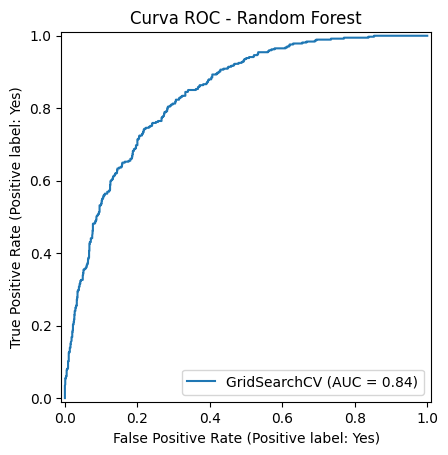

In [ ]:
# ROC Curve
RocCurveDisplay.from_estimator(grid_rf, X_test, y_test)
plt.title('Curva ROC - Random Forest')
plt.show()

### Tabla comparativa

In [ ]:
# Tabla comparativa
results = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [acc_lr, acc_rf],
    'F1 Score': [f1_lr, f1_rf]
})

print("\nTabla comparativa:")
print(results)


Tabla comparativa:
                Modelo  Accuracy  F1 Score
0  Logistic Regression  0.798439  0.572289
1        Random Forest  0.795600  0.520000


### Matriz de confusion

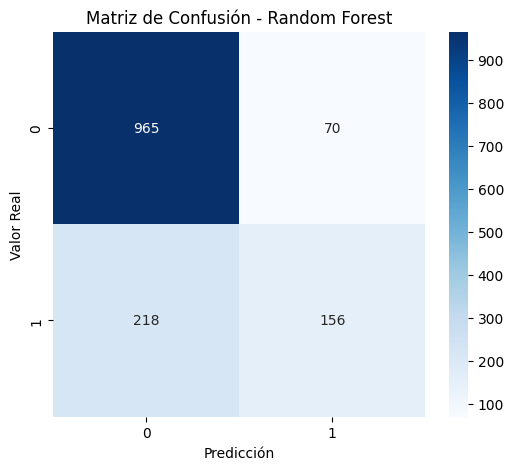

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

# Seccion 6: Conclusiones

Conclusiones:

1. Sí es posible predecir la cancelación de clientes
utilizando modelos de Machine Learning.

2. Random Forest obtuvo mejor desempeño general
gracias a su capacidad de modelar relaciones complejas.

3. El uso de Pipeline evitó data leakage al ajustar
las transformaciones únicamente sobre entrenamiento.

4. La métrica F1 fue adecuada debido al desbalance
moderado de clases.

5. El modelo puede utilizarse como apoyo para
estrategias de retención de clientes.

Limitaciones:
- Dataset limitado
- Variables externas no consideradas
- Posible necesidad de balanceo avanzado

Mejoras futuras:
- Aplicar XGBoost
- Utilizar SMOTE
- Ingeniería de variables
- Explainable AI (SHAP)
""")